# Lab 1 — Quá trình Poisson và Mô phỏng Hàng đợi M/M/1, M/M/n
**Môn:** NT531 — Đánh giá hiệu năng Mạng máy tính

| Thông tin | |
|---|---|
| **Họ và tên** | *(điền tên)* |
| **MSSV** | *(điền MSSV)* |

## Cài đặt và Import thư viện
Chạy cell bên dưới để cài đặt các thư viện cần thiết (nếu chưa có) và import.

In [1]:
# Cài đặt thư viện (bỏ comment nếu cần)
# !pip install numpy matplotlib scipy simpy

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import simpy

# Cấu hình đồ thị
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

# Đặt seed để kết quả tái lập được
np.random.seed(42)

---
# PHẦN 1: QUÁ TRÌNH ĐẾN POISSON
---

**Kịch bản:** Gói tin đến một bộ định tuyến mạng theo quá trình Poisson với tốc độ $\lambda = 5$ gói/giây.

Trong phần này, ta sẽ:
- Sinh thời gian giữa các lần đến (inter-arrival times) bằng phương pháp inverse transform
- Đếm số gói đến trong mỗi khe thời gian (time slot)
- So sánh phân phối thực nghiệm với phân phối Poisson lý thuyết

**Tham số:**
- $\lambda = 5$ gói/giây
- $N = 200$ gói tin
- Kích thước khe thời gian: $T_s = N / (\lambda \times \text{num\_slots})$

In [2]:
# Tham số Phần 1
lam = 5          # Tốc độ đến (gói/giây)
N = 200          # Số gói tin
num_slots = 40   # Số khe thời gian
Ts = N / (lam * num_slots)  # Kích thước mỗi khe thời gian

print(f"λ = {lam} gói/giây")
print(f"N = {N} gói")
print(f"Số khe thời gian = {num_slots}")
print(f"Ts = {Ts:.4f} giây")
print(f"λ × Ts = {lam * Ts:.2f} (số gói trung bình mỗi khe)")

λ = 5 gói/giây
N = 200 gói
Số khe thời gian = 40
Ts = 1.0000 giây
λ × Ts = 5.00 (số gói trung bình mỗi khe)


In [3]:
# ============================================================
# TODO 1: Sinh thời gian giữa các lần đến (inter-arrival times)
#          bằng phương pháp inverse transform
# ============================================================
# Gợi ý: inter_arrival = (-1/lam) * np.log(1 - np.random.rand(N))
#
# Code của bạn ở đây:
inter_arrival = (-1/lam) * np.log(1 - np.random.rand(N))

In [4]:
# ============================================================
# TODO 2: Tính thời gian đến tích lũy (cumulative arrival times)
# ============================================================
# Gợi ý: arrival_times = np.cumsum(inter_arrival)
#
# Code của bạn ở đây:
arrival_times = np.cumsum(inter_arrival)

# Kiểm tra: in 10 thời gian đến đầu tiên
print("10 thời gian đến đầu tiên:")
print(arrival_times[:10])

10 thời gian đến đầu tiên:
[0.09385362 0.6958779  0.95922704 1.14181555 1.17574053 1.20965979
 1.22162754 1.62387371 1.80769014 2.05394016]


In [5]:
# ============================================================
# TODO 3: Đếm số gói đến trong mỗi khe thời gian
# ============================================================
slot_edges = np.arange(0, num_slots + 1) * Ts
counts, _ = np.histogram(arrival_times, bins=slot_edges)

print(f"Số gói đến mỗi khe (10 khe đầu): {counts[:10]}")

Số gói đến mỗi khe (10 khe đầu): [ 3  6  3 11  7  4  5  6  5  2]


In [6]:
# ============================================================
# TODO 4: Tính PMF thực nghiệm — f(x) và %real
# ============================================================
max_k = int(counts.max())
k_values = np.arange(0, max_k + 1)
empirical_pmf = np.array([np.sum(counts == k) / num_slots for k in k_values])

print("k | f(k)  | %real")
print("-" * 25)
for k, p in zip(k_values, empirical_pmf):
    print(f"{k} | {p:.4f} | {p*100:.1f}%")

k | f(k)  | %real
-------------------------
0 | 0.0500 | 5.0%
1 | 0.0000 | 0.0%
2 | 0.0500 | 5.0%
3 | 0.1750 | 17.5%
4 | 0.1750 | 17.5%
5 | 0.2000 | 20.0%
6 | 0.1250 | 12.5%
7 | 0.0750 | 7.5%
8 | 0.0250 | 2.5%
9 | 0.0750 | 7.5%
10 | 0.0250 | 2.5%
11 | 0.0250 | 2.5%


In [7]:
# ============================================================
# TODO 5: Tính PMF lý thuyết Poisson — %theory
# ============================================================
theoretical_pmf = stats.poisson.pmf(k_values, mu=lam * Ts)

print("k | %theory")
print("-" * 20)
for k, p in zip(k_values, theoretical_pmf):
    print(f"{k} | {p*100:.1f}%")

k | %theory
--------------------
0 | 0.7%
1 | 3.4%
2 | 8.4%
3 | 14.0%
4 | 17.5%
5 | 17.5%
6 | 14.6%
7 | 10.4%
8 | 6.5%
9 | 3.6%
10 | 1.8%
11 | 0.8%


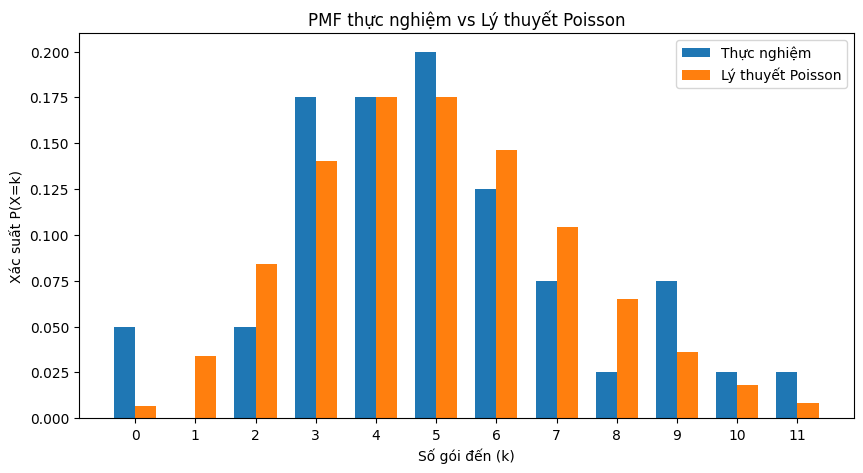

In [8]:
# ============================================================
# TODO 6: Vẽ biểu đồ cột — PMF thực nghiệm vs lý thuyết
# ============================================================
width = 0.35
plt.bar(k_values - width/2, empirical_pmf, width, label='Thực nghiệm')
plt.bar(k_values + width/2, theoretical_pmf, width, label='Lý thuyết Poisson')
plt.xlabel('Số gói đến (k)')
plt.ylabel('Xác suất P(X=k)')
plt.title('PMF thực nghiệm vs Lý thuyết Poisson')
plt.xticks(k_values)
plt.legend()
plt.show()

In [9]:
# ============================================================
# TODO 7: In trung bình và phương sai của số gói đến mỗi khe
# ============================================================
mean_counts = np.mean(counts)
var_counts = np.var(counts)

print(f"Trung bình (mean) số gói/khe:  {mean_counts:.4f}")
print(f"Phương sai (variance):          {var_counts:.4f}")
print(f"Giá trị lý thuyết (λ×Ts):      {lam * Ts:.4f}")
print(f"\nNhận xét: mean ≈ variance ≈ λ×Ts → đúng tính chất Poisson")

Trung bình (mean) số gói/khe:  5.0000
Phương sai (variance):          5.9500
Giá trị lý thuyết (λ×Ts):      5.0000

Nhận xét: mean ≈ variance ≈ λ×Ts → đúng tính chất Poisson


---
# PHẦN 2: MÔ PHỎNG HÀNG ĐỢI M/M/1 (PYTHON THUẦN)
---

## Ký hiệu Kendall: M/M/1
- **M** (Markovian): Thời gian đến tuân theo phân phối mũ → quá trình Poisson
- **M** (Markovian): Thời gian phục vụ tuân theo phân phối mũ
- **1**: 1 server (bộ phục vụ)

## Các công thức M/M/1

| Ký hiệu | Công thức | Ý nghĩa |
|:---:|:---:|:---|
| $\rho$ | $\lambda / \mu$ | Hệ số sử dụng (utilization), yêu cầu $\rho < 1$ |
| $L$ | $\rho / (1 - \rho)$ | Số trung bình trong hệ thống |
| $L_q$ | $\rho^2 / (1 - \rho)$ | Số trung bình trong hàng đợi |
| $W$ | $1 / (\mu - \lambda)$ | Thời gian trung bình trong hệ thống |
| $W_q$ | $\rho / (\mu - \lambda)$ | Thời gian chờ trung bình trong hàng đợi |

**Kịch bản:** $\lambda = 5$ gói/giây, $\mu = 8$ gói/giây, mô phỏng $N = 10.000$ gói.

In [10]:
# Tham số Phần 2
lam = 5           # Tốc độ đến (gói/giây)
mu = 8            # Tốc độ phục vụ (gói/giây)
num_packets = 10000  # Số gói tin mô phỏng

rho_theory = lam / mu
print(f"λ = {lam}, μ = {mu}")
print(f"ρ = λ/μ = {rho_theory:.4f}")
print(f"Hệ thống {'ổn định' if rho_theory < 1 else 'KHÔNG ổn định'}")
print(f"Số gói mô phỏng: {num_packets}")

λ = 5, μ = 8
ρ = λ/μ = 0.6250
Hệ thống ổn định
Số gói mô phỏng: 10000


In [11]:
# ============================================================
# TODO 8: Sinh thời gian giữa các lần đến (exponential, rate λ)
# ============================================================
inter_arrival = np.random.exponential(1/lam, num_packets)

In [12]:
# ============================================================
# TODO 9: Sinh thời gian phục vụ (exponential, rate μ)
# ============================================================
service_time = np.random.exponential(1/mu, num_packets)

In [13]:
# ============================================================
# TODO 10: Vòng lặp mô phỏng M/M/1 (event-driven)
# ============================================================
arrival_time = np.zeros(num_packets)
service_start = np.zeros(num_packets)
departure_time = np.zeros(num_packets)
wait_time = np.zeros(num_packets)

# Gói đầu tiên (i=0)
arrival_time[0] = inter_arrival[0]
service_start[0] = arrival_time[0]
departure_time[0] = service_start[0] + service_time[0]
wait_time[0] = 0

for i in range(1, num_packets):
    arrival_time[i] = arrival_time[i-1] + inter_arrival[i]
    service_start[i] = max(arrival_time[i], departure_time[i-1])
    departure_time[i] = service_start[i] + service_time[i]
    wait_time[i] = service_start[i] - arrival_time[i]

print("Mô phỏng hoàn tất!")
print(f"Thời gian mô phỏng: {departure_time[-1]:.2f} giây")

Mô phỏng hoàn tất!
Thời gian mô phỏng: 1956.05 giây


In [14]:
# ============================================================
# TODO 11: Tính các chỉ số mô phỏng
# ============================================================
W_sim = np.mean(departure_time - arrival_time)
Wq_sim = np.mean(wait_time)
L_sim = W_sim * lam
Lq_sim = Wq_sim * lam
rho_sim = np.sum(service_time) / departure_time[-1]

print("=== Kết quả mô phỏng ===")
print(f"ρ (sim)  = {rho_sim:.4f}")
print(f"L (sim)  = {L_sim:.4f}")
print(f"Lq (sim) = {Lq_sim:.4f}")
print(f"W (sim)  = {W_sim:.4f} giây")
print(f"Wq (sim) = {Wq_sim:.4f} giây")

=== Kết quả mô phỏng ===
ρ (sim)  = 0.6504
L (sim)  = 1.7818
Lq (sim) = 1.1457
W (sim)  = 0.3564 giây
Wq (sim) = 0.2291 giây


In [15]:
# ============================================================
# TODO 12: Tính các chỉ số lý thuyết M/M/1
# ============================================================
rho_th = lam / mu
L_th = rho_th / (1 - rho_th)
Lq_th = rho_th**2 / (1 - rho_th)
W_th = 1 / (mu - lam)
Wq_th = rho_th / (mu - lam)

print("=== Kết quả lý thuyết M/M/1 ===")
print(f"ρ  = {rho_th:.4f}")
print(f"L  = {L_th:.4f}")
print(f"Lq = {Lq_th:.4f}")
print(f"W  = {W_th:.4f} giây")
print(f"Wq = {Wq_th:.4f} giây")

=== Kết quả lý thuyết M/M/1 ===
ρ  = 0.6250
L  = 1.6667
Lq = 1.0417
W  = 0.3333 giây
Wq = 0.2083 giây


In [16]:
# ============================================================
# TODO 13: In bảng so sánh — mô phỏng vs lý thuyết
# ============================================================
metrics = [
    ("ρ",  rho_sim, rho_th),
    ("L",  L_sim,   L_th),
    ("Lq", Lq_sim,  Lq_th),
    ("W",  W_sim,   W_th),
    ("Wq", Wq_sim,  Wq_th),
]

print(f"{'Chỉ số':<8} {'Mô phỏng':>12} {'Lý thuyết':>12} {'Sai số (%)':>12}")
print("-" * 48)
for name, sim, th in metrics:
    err = abs(sim - th) / th * 100
    print(f"{name:<8} {sim:>12.4f} {th:>12.4f} {err:>11.2f}%")

Chỉ số       Mô phỏng    Lý thuyết   Sai số (%)
------------------------------------------------
ρ              0.6504       0.6250        4.06%
L              1.7818       1.6667        6.91%
Lq             1.1457       1.0417        9.99%
W              0.3564       0.3333        6.91%
Wq             0.2291       0.2083        9.99%


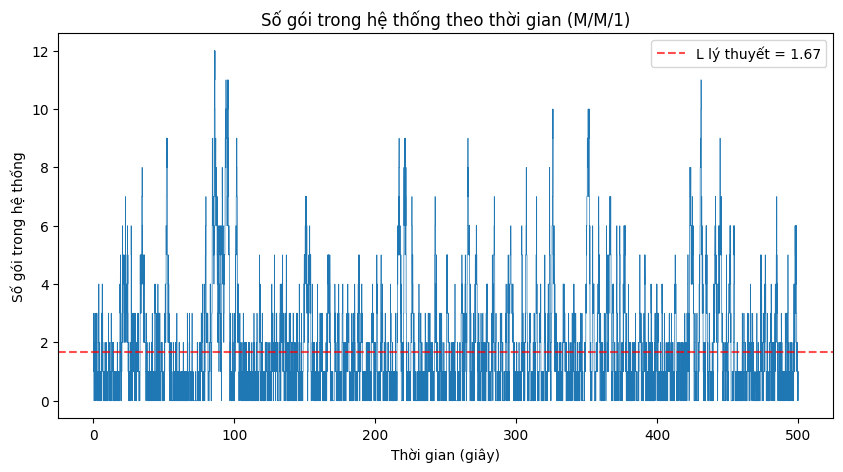

In [17]:
# ============================================================
# TODO 14: Vẽ biểu đồ — Số gói trong hàng đợi theo thời gian
# ============================================================
# Tạo sự kiện: arrival = +1, departure = -1
event_times = np.concatenate([arrival_time, departure_time])
event_types = np.concatenate([np.ones(num_packets), -np.ones(num_packets)])
order = np.argsort(event_times)
event_times = event_times[order]
event_types = event_types[order]
num_in_system = np.cumsum(event_types)

# Chỉ vẽ 500 giây đầu để dễ nhìn
mask = event_times <= 500
plt.step(event_times[mask], num_in_system[mask], where='post', linewidth=0.5)
plt.xlabel('Thời gian (giây)')
plt.ylabel('Số gói trong hệ thống')
plt.title('Số gói trong hệ thống theo thời gian (M/M/1)')
plt.axhline(y=L_th, color='r', linestyle='--', alpha=0.7, label=f'L lý thuyết = {L_th:.2f}')
plt.legend()
plt.show()

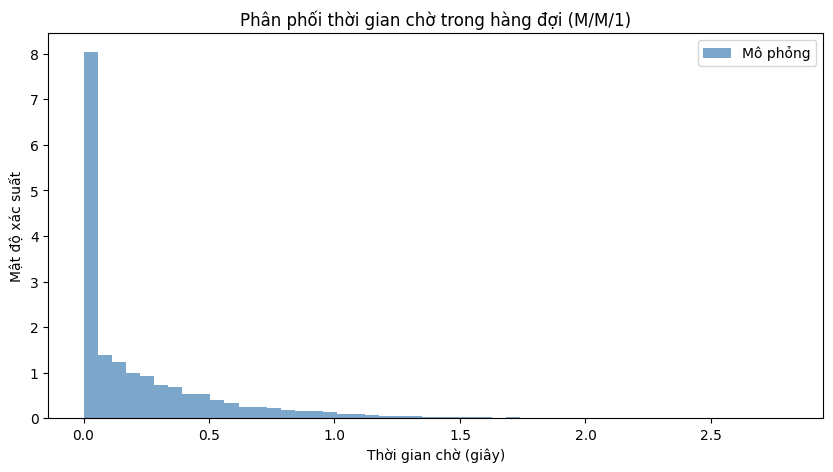

In [18]:
# ============================================================
# TODO 15: Vẽ histogram thời gian chờ
# ============================================================
plt.hist(wait_time, bins=50, density=True, alpha=0.7, label='Mô phỏng', color='steelblue')
plt.xlabel('Thời gian chờ (giây)')
plt.ylabel('Mật độ xác suất')
plt.title('Phân phối thời gian chờ trong hàng đợi (M/M/1)')
plt.legend()
plt.show()

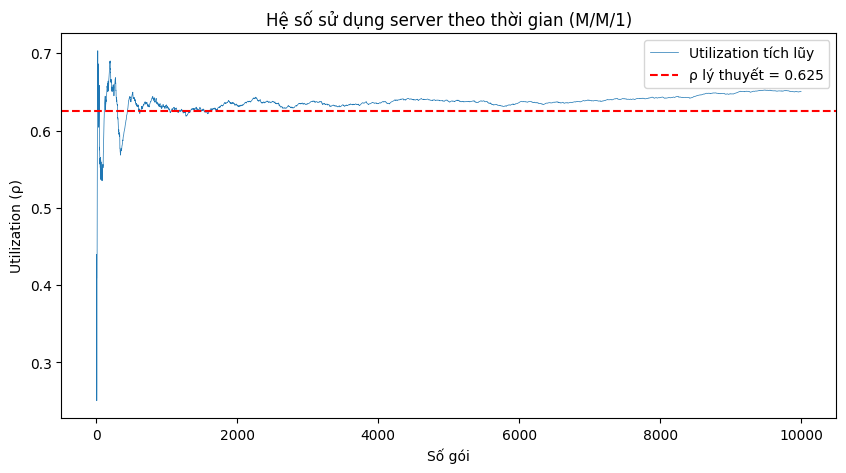

In [19]:
# ============================================================
# TODO 16: Vẽ hệ số sử dụng server theo thời gian (rolling average)
# ============================================================
busy_cumsum = np.cumsum(service_time)
utilization = busy_cumsum / departure_time

plt.plot(np.arange(1, num_packets+1), utilization, linewidth=0.5, label='Utilization tích lũy')
plt.axhline(y=rho_th, color='r', linestyle='--', label=f'ρ lý thuyết = {rho_th:.3f}')
plt.xlabel('Số gói')
plt.ylabel('Utilization (ρ)')
plt.title('Hệ số sử dụng server theo thời gian (M/M/1)')
plt.legend()
plt.show()

---
# PHẦN 3: MÔ PHỎNG BẰNG SIMPY + M/M/n
---

## SimPy là gì?
[SimPy](https://simpy.readthedocs.io/) là thư viện mô phỏng sự kiện rời rạc (discrete-event simulation) cho Python.

Các khái niệm chính:
- **Environment**: Quản lý thời gian mô phỏng
- **Process**: Các tiến trình (ví dụ: gói tin đến, xử lý)
- **Resource**: Tài nguyên có giới hạn (ví dụ: server)

Với `simpy.Resource(env, capacity=n)`, ta dễ dàng mô phỏng hệ thống M/M/n.

In [20]:
# ============================================================
# TODO 17: Mô phỏng M/M/1 bằng SimPy
# ============================================================

def simpy_mm1(lam, mu, num_packets, num_servers=1):
    """Mô phỏng M/M/n bằng SimPy. Trả về danh sách thời gian chờ."""
    wait_times = []
    
    def packet(env, server, mu):
        """Process: một gói tin đến, chờ server, được xử lý."""
        arrive = env.now
        with server.request() as req:
            yield req
            wait = env.now - arrive
            wait_times.append(wait)
            yield env.timeout(np.random.exponential(1/mu))
    
    def packet_generator(env, server, lam, mu, num_packets):
        """Process: sinh gói tin theo quá trình Poisson."""
        for i in range(num_packets):
            yield env.timeout(np.random.exponential(1/lam))
            env.process(packet(env, server, mu))
    
    # Tạo môi trường SimPy và chạy
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=num_servers)
    env.process(packet_generator(env, server, lam, mu, num_packets))
    env.run()
    
    return wait_times

# Chạy M/M/1 bằng SimPy
np.random.seed(42)
wait_times_simpy = simpy_mm1(lam=5, mu=8, num_packets=10000, num_servers=1)

Wq_simpy = np.mean(wait_times_simpy)
W_simpy = Wq_simpy + 1/mu
L_simpy = lam * W_simpy
Lq_simpy = lam * Wq_simpy

print("=== Kết quả SimPy M/M/1 ===")
print(f"Wq (SimPy) = {Wq_simpy:.4f} giây")
print(f"W  (SimPy) = {W_simpy:.4f} giây")
print(f"Lq (SimPy) = {Lq_simpy:.4f}")
print(f"L  (SimPy) = {L_simpy:.4f}")

=== Kết quả SimPy M/M/1 ===
Wq (SimPy) = 0.2275 giây
W  (SimPy) = 0.3525 giây
Lq (SimPy) = 1.1377
L  (SimPy) = 1.7627


In [21]:
# ============================================================
# TODO 18: So sánh SimPy M/M/1 vs Python thuần (Phần 2)
# ============================================================
print(f"{'Chỉ số':<8} {'Python thuần':>14} {'SimPy':>14} {'Lý thuyết':>14}")
print("-" * 56)
for name, py_val, sp_val, th_val in [
    ("W",  W_sim,  W_simpy,  W_th),
    ("Wq", Wq_sim, Wq_simpy, Wq_th),
    ("L",  L_sim,  L_simpy,  L_th),
    ("Lq", Lq_sim, Lq_simpy, Lq_th),
]:
    print(f"{name:<8} {py_val:>14.4f} {sp_val:>14.4f} {th_val:>14.4f}")

Chỉ số     Python thuần          SimPy      Lý thuyết
--------------------------------------------------------
W                0.3564         0.3525         0.3333
Wq               0.2291         0.2275         0.2083
L                1.7818         1.7627         1.6667
Lq               1.1457         1.1377         1.0417


In [22]:
# ============================================================
# TODO 19: Mở rộng sang M/M/n
# ============================================================
lam_mmn = 5
mu_mmn = 3
servers_list = [2, 3, 4, 5]

Wq_results = {}

for n in servers_list:
    rho_n = lam_mmn / (n * mu_mmn)
    if rho_n >= 1:
        print(f"n={n}: ρ = {rho_n:.3f} >= 1 → hệ thống không ổn định, bỏ qua.")
        continue
    np.random.seed(42)
    wt = simpy_mm1(lam_mmn, mu_mmn, 10000, num_servers=n)
    Wq_results[n] = np.mean(wt)

print("\n=== Kết quả M/M/n ===")
print(f"{'n':>4} {'ρ per server':>14} {'Wq (giây)':>14}")
print("-" * 36)
for n, wq in sorted(Wq_results.items()):
    rho_n = lam_mmn / (n * mu_mmn)
    print(f"{n:>4} {rho_n:>14.4f} {wq:>14.4f}")


=== Kết quả M/M/n ===
   n   ρ per server      Wq (giây)
------------------------------------
   2         0.8333         0.6752
   3         0.5556         0.0888
   4         0.4167         0.0145
   5         0.3333         0.0026


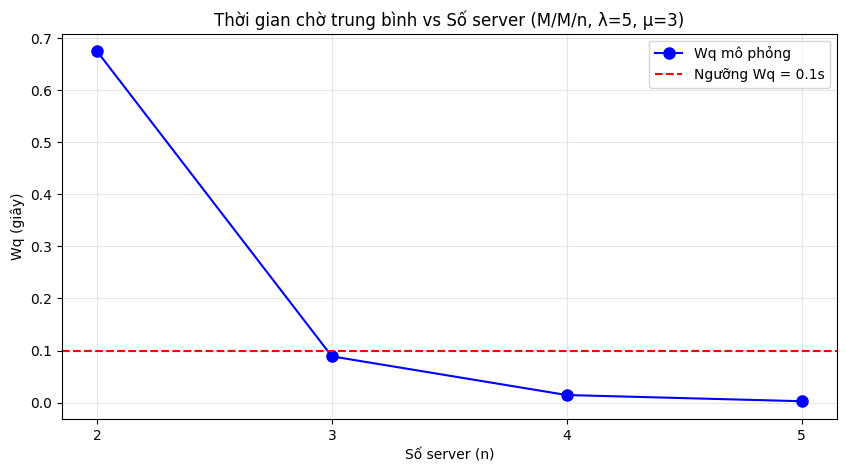

In [23]:
# ============================================================
# TODO 20: Vẽ biểu đồ — Wq vs số server n
# ============================================================
plt.plot(list(Wq_results.keys()), list(Wq_results.values()), 'bo-', markersize=8, label='Wq mô phỏng')
plt.axhline(y=0.1, color='r', linestyle='--', label='Ngưỡng Wq = 0.1s')
plt.xlabel('Số server (n)')
plt.ylabel('Wq (giây)')
plt.title('Thời gian chờ trung bình vs Số server (M/M/n, λ=5, μ=3)')
plt.xticks(list(Wq_results.keys()))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Câu hỏi thảo luận

Trả lời các câu hỏi sau trong báo cáo:

**Q1:** Khi $\rho \to 1$, điều gì xảy ra với thời gian chờ $W_q$? Giải thích bằng công thức và bằng kết quả mô phỏng.

**Q2:** So sánh kết quả mô phỏng M/M/1 giữa Python thuần (Phần 2) và SimPy (Phần 3). Có khác biệt đáng kể không? Giải thích tại sao.

**Q3:** Với M/M/n, cho $\lambda = 5$ gói/giây và $\mu = 3$ gói/giây, cần bao nhiêu server để $W_q < 0{.}1$ giây? Trả lời bằng cách chạy mô phỏng với các giá trị $n$ khác nhau.

---
*Hết bài lab 1.*